# 04_概率分布-Beta分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文，咱们聊聊概率分布中的Beta分布\~

在日常生活和科学研究中，我们经常会遇到“概率”这样一个概念：比如投掷一枚硬币，正面朝上的概率是 0.5；抛掷一个六面骰子，出现“6”的概率是 1/6。

很多时候，我们对某件事的“未知概率”抱有一种不确定的主观信念，比如：“这个网站的用户明天会有多少人注册？”或者“这位候选人在选举中获胜的概率是多少？”

**Beta 分布**正是一种用来描述这种“对未知概率”的不确定程度的概率分布。它是定义在区间 $0,1$ 上的连续分布，通过两个参数 $\alpha$ 和 $\beta$（均大于 0）来控制分布的形状。

- 当 $\alpha$ 和 $\beta$ 都小于 1 时，分布在 0 和 1 附近呈现“U 型”，意味着我们更倾向于相信概率接近 0 或接近 1，却对中间值不太相信。
- 当 $\alpha = \beta = 1$ 时，Beta(1,1) 就是区间 $0,1$ 上的均匀分布，表示对所有概率值一视同仁，没有偏好。
- 当 $\alpha>1,\ \beta>1$ 且相等时，分布在 0.5 附近呈现山峰；如果 $\alpha>\beta$，山峰偏向 1，说明我们更相信概率较大；反之则偏向 0。

### 简单例子：抛硬币的“信念更新”

1. **初始信念**：假设我们一开始并不知道这枚硬币是否公平，于是我们可以选择一个无偏的先验分布 Beta(1,1)，即在 0\~1 任何值都认为一样可能。
2. **观察数据**：我们连续抛了 10 次，结果出现了 7 次正面，3 次反面。
3. **更新先验**：在 Beta 分布的性质下，看到 $k$ 次正面、$n-k$ 次反面后，后验分布为  
$\text{Beta}(\alpha_{\text{new}},\beta_{\text{new}})= \text{Beta}(\alpha_{\text{old}} + k,\ \beta_{\text{old}} + n - k)$  
代入 $\alpha_{\text{old}}=1,\ \beta_{\text{old}}=1,\ k=7,\ n-k=3$，得到后验为 Beta(8,4)。
4. **解读**：Beta(8,4) 表示当前我们对“硬币出现正面的真实概率”更倾向于认为在 0.6\~0.8 之间，因为该分布在这个区间有较高的密度。

大家可以直观感受到 Beta 分布的本质：它是一种“先验—更新—后验”框架中的核心分布，用于用观测数据来不断修正对“成功概率”的信念。

## 公式推导

### 1. 定义与归一化常数

Beta 分布在区间 $[0,1]$ 上的概率密度函数（PDF）定义为：


$$
f(x; \alpha, \beta)= \frac{1}{B(\alpha,\beta)} \, x^{\alpha-1} (1-x)^{\beta-1},\quad 0 \le x \le 1,
$$


其中 $B(\alpha,\beta)$ 是 Beta 函数，用于保证分布的总面积为 1：


$$
B(\alpha,\beta)= \int_{0}^{1} t^{\alpha-1} (1-t)^{\beta-1} \, dt.
$$


Beta 函数与 Gamma 函数 $\Gamma(z)$（一个广义阶乘函数）之间有如下关系：


$$
B(\alpha,\beta)= \frac{\Gamma(\alpha)\,\Gamma(\beta)}{\Gamma(\alpha+\beta)}.
$$


Gamma 函数满足：


$$
\Gamma(z) = \int_{0}^{+\infty} t^{z-1} e^{-t}\,dt,\quad\Gamma(n)=(n-1)!\quad(n\in\mathbb{N^+}).
$$


**推导归一化常数**

1. 从 Beta 函数的定义出发：


$$
B(\alpha,\beta)= \int_{0}^{1} t^{\alpha-1} (1-t)^{\beta-1}\,dt.
$$


1. 利用 Gamma 函数的欧拉积分表达式，并做变量替换，可以得到：


$$
\int_{0}^{+\infty} u^{\alpha-1} e^{-u}\,du= \Gamma(\alpha),\quad\int_{0}^{+\infty} v^{\beta-1} e^{-v}\,dv= \Gamma(\beta).
$$


1. 通过二重积分和变量替换（令 $u = xt$，$v = (1-x)t$，$\,t=u+v$），可将  
$\Gamma(\alpha)\Gamma(\beta)$ 与 Beta 函数联系起来，从而证明


$$
B(\alpha,\beta)= \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}.
$$


### 2. 一阶矩、二阶矩（均值与方差）

利用 Beta 分布的 PDF，可以推导出它的均值和方差：

1. **均值**  
$\mathbb{E}[X]= \int_{0}^{1} x \, f(x;\alpha,\beta)\,dx= \frac{\alpha}{\alpha+\beta}.$
2. **方差**  
$\mathrm{Var}(X)= \int_{0}^{1} x^2\,f(x)\,dx - \bigl(\mathbb{E}[X]\bigr)^2= \frac{\alpha\,\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}.$

**推导要点**

- 均值推导中，利用 Beta 函数的递推性质：  
$B(\alpha+1,\beta)= \frac{\alpha}{\alpha+\beta} \, B(\alpha,\beta).$
- 方差推导则需要计算二阶矩 $\mathbb{E}[X^2]$，同样利用 Beta 函数递推并结合均值公式即可。

### 3. 后验更新（Beta–Bernoulli 共轭性）

当我们将 Beta 分布作为 Bernoulli（或二项分布）参数 $p$ 的先验分布时，观测到 $k$ 次成功、$n-k$ 次失败后，后验分布仍然是一个 Beta 分布：  
$\text{Prior:}\quad p \sim \mathrm{Beta}(\alpha,\beta),\qquad\text{Likelihood:}\quad \mathrm{Bernoulli}(p)^n,$  
$\text{Posterior:}\quad p \mid \text{data}\sim \mathrm{Beta}(\alpha + k,\ \beta + n - k).$  
这种共轭性质（conjugacy）让贝叶斯推断的数值计算变得极其简洁。

## Python实现

下面，咱们用 Python 来生成 Beta 分布的随机样本，进行可视化，以及在机器学习任务（如 A/B 测试）中应用 Beta 分布进行贝叶斯推断。

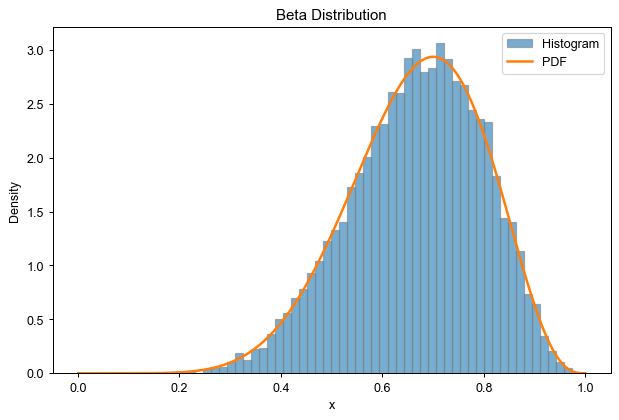

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# 生成 Beta 分布样本
alpha, beta_param = 8, 4
samples = np.random.beta(alpha, beta_param, size=10000)

# 绘制直方图 + PDF 曲线
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, density=True, alpha=0.6, edgecolor='gray', label='Histogram')
x = np.linspace(0, 1, 200)
pdf = beta.pdf(x, alpha, beta_param)
plt.plot(x, pdf, linewidth=2, label='PDF')
plt.title('Beta Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_023.png)

### 机器学习应用示例：贝叶斯 A/B 测试

那么，在 A/B 测试中，我们经常关心哪种版本（A 或 B）的转化率更高。我们可以用 Beta 分布作为两组的先验，然后基于观测数据更新后验，并比较两者的分布。

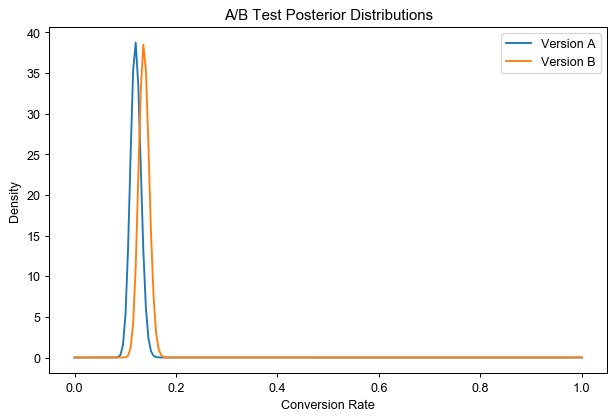

Probability that A is better than B: 0.132


In [3]:
import numpy as np
from scipy.stats import beta

# 假设版本 A：观测到 120 次转化 / 1000 次展示
#      版本 B：观测到 150 次转化 / 1100 次展示
a_success, a_trials = 120, 1000
b_success, b_trials = 150, 1100

# 设定非信息先验 Beta(1,1)
a_alpha_post = 1 + a_success
a_beta_post  = 1 + (a_trials - a_success)
b_alpha_post = 1 + b_success
b_beta_post  = 1 + (b_trials - b_success)

# 在 [0,1] 区间上比较两个后验分布
x = np.linspace(0, 1, 200)
a_pdf = beta.pdf(x, a_alpha_post, a_beta_post)
b_pdf = beta.pdf(x, b_alpha_post, b_beta_post)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(x, a_pdf, label='Version A')
plt.plot(x, b_pdf, label='Version B')
plt.title('A/B Test Posterior Distributions') 
plt.xlabel('Conversion Rate')
plt.ylabel('Density')
plt.legend()
plt.show()

# 计算 P(A > B) 的概率（蒙特卡洛模拟）
samples_a = np.random.beta(a_alpha_post, a_beta_post, size=1000000)
samples_b = np.random.beta(b_alpha_post, b_beta_post, size=1000000)
prob_a_beats_b = np.mean(samples_a > samples_b)
print(f"Probability that A is better than B: {prob_a_beats_b:.3f}")

xxx(img/04_概率分布-Beta分布-2.png)

- 这段代码中，我们先用 Beta(1,1) 作为先验，再根据各自的转化数据更新后验。
- 绘制得到两条后验密度曲线，可以直观比较哪一个版本的转化率更高。
- 最后用蒙特卡洛模拟计算“版本 A 的转化率高于版本 B”的概率。

通过上述内容，大家可以在以下几个层面上掌握 Beta 分布：

1. **直观层面**：它是描述区间 $0,1$ 上不确定概率的一种分布，有多种形状；
2. **数学层面**：它的 PDF 包含 Beta 函数（与 Gamma 函数关联），可推导均值、方差和后验更新公式；
3. **实践层面**：在 Python 中轻松生成样本、可视化，并在 A/B 测试、贝叶斯推断等机器学习任务中。